In [2]:
#import libraries
import pandas as pd
import numpy as np

In [3]:
#load dataset
data=pd.read_csv('salary.csv')
data

,age,education.num,capital.gain,hours.per.week,income
0,90,9,0,40,<=50K
1,82,9,0,18,<=50K
2,66,10,0,40,<=50K
3,54,4,0,40,<=50K
4,41,10,0,40,<=50K
...,...,...,...,...,...
32556,22,10,0,40,<=50K
32557,27,12,0,38,<=50K
32558,40,9,0,40,>50K
32559,58,9,0,40,<=50K


In [4]:
#summarize dataset
data.shape
data.head()


,age,education.num,capital.gain,hours.per.week,income
0,90,9,0,40,<=50K
1,82,9,0,18,<=50K
2,66,10,0,40,<=50K
3,54,4,0,40,<=50K
4,41,10,0,40,<=50K


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [19]:
#segregate dataset
x=data.iloc[:,:-1].values
x

array([[90,  9,  0, 40],
       [82,  9,  0, 18],
       [66, 10,  0, 40],
       ...,
       [40,  9,  0, 40],
       [58,  9,  0, 40],
       [22,  9,  0, 20]], shape=(32561, 4))

In [20]:
y=data.iloc[:,-1].values
y

array(['<=50K', '<=50K', '<=50K', ..., '>50K', '<=50K', '<=50K'],
      shape=(32561,), dtype=object)

In [21]:
#splitting dataset
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train,x_test)

[[  55    3    0   40]
 [  42    9    0   40]
 [  42    9    0   40]
 ...
 [  26    8    0   51]
 [  44   14    0   40]
 [  39    9 7298   40]] [[56  5  0 40]
 [19  9  0 25]
 [23 10  0 35]
 ...
 [44 10  0 55]
 [58  9  0 50]
 [55 10  0 45]]


In [30]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
print(x_train,x_test)

[[ 1.20264866 -2.76154633 -0.14509813 -0.03923011]
 [ 0.25021666 -0.42608063 -0.14509813 -0.03923011]
 [ 0.25021666 -0.42608063 -0.14509813 -0.03923011]
 ...
 [-0.92200734 -0.81532491 -0.14509813  0.85306386]
 [ 0.39674466  1.52014079 -0.14509813 -0.03923011]
 [ 0.03042466 -0.42608063  0.83219401 -0.03923011]] [[ 1.27591266 -1.98305776 -0.14509813 -0.03923011]
 [-1.43485534 -0.42608063 -0.14509813 -1.25599461]
 [-1.14179934 -0.03683634 -0.14509813 -0.44481828]
 ...
 [ 0.39674466 -0.03683634 -0.14509813  1.1775344 ]
 [ 1.42244067 -0.42608063 -0.14509813  0.77194623]
 [ 1.20264866 -0.03683634 -0.14509813  0.36635806]]


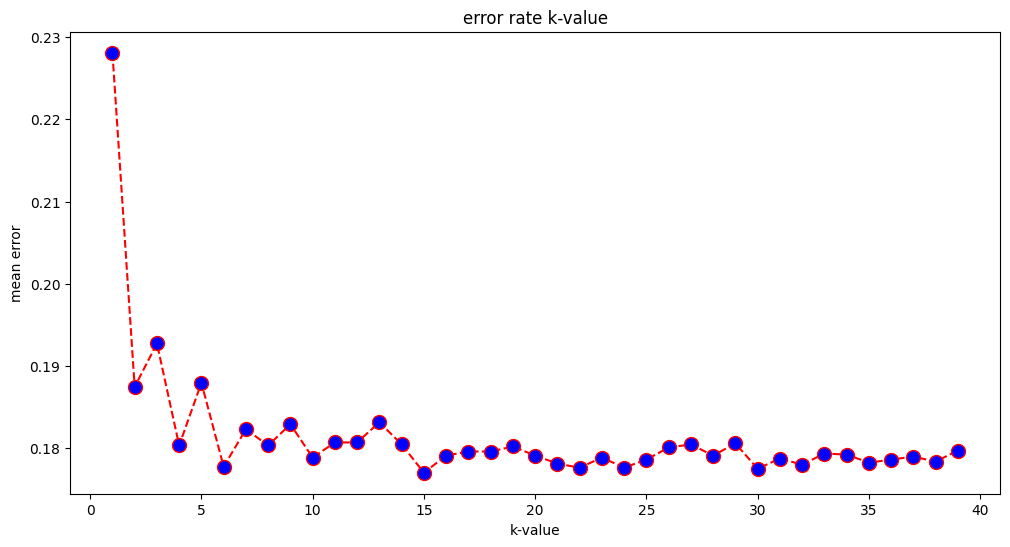

In [24]:
#finding the k value
error=[]
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
#calculating error for k value between 1 and 40
for i in range(1,40):
    model= KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    pred_i=model.predict(x_test)
    error.append(np.mean(pred_i!=y_test))
plt.figure(figsize=(12,6))
plt.plot(range(1,40),error,color='red',linestyle='dashed',marker='o',markerfacecolor='blue',markersize=10)
plt.title('error rate k-value')
plt.xlabel('k-value')
plt.ylabel('mean error')
plt.show()

In [23]:
#training
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=2,metric='minkowski',p=2)
model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=2)

In [31]:
#predicting whether new customer with age and salary will buy or not
age=int(input("enter thr new customer age:"))
edu=int(input("enter the new customer edu:"))
cg=int(input("enter the new customer cg:"))
wh=int(input("enter the new customer wh:"))
newEmp=[[age,edu,cg,wh]]
result=model.predict(sc.transform(newEmp))
print(result)
if result==1:
    print("customer might got salary above 50k")
else:
    print("customer might got not salary above 50k")

enter thr new customer age: 3
enter the new customer edu: 2
enter the new customer cg: 3
enter the new customer wh: 4


['<=50K']
customer might got not salary above 50k


In [26]:
#predicting all test data
y_pred=model.predict(x_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[['<=50K' '<=50K']
 ['<=50K' '<=50K']
 ['<=50K' '<=50K']
 ...
 ['<=50K' '<=50K']
 ['<=50K' '<=50K']
 ['<=50K' '<=50K']]


In [27]:
#accuracy score
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred)*100)

82.0292347377472
